## Packages

In [1]:
import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.3 scipy==1.9.1 pandas==1.5.0 scikit-learn==1.1.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


In [2]:
import batchglm.api as glm
import diffxpy.api as de

print("batchglm version "+glm.__version__)
print("diffpy version "+de.__version__)

batchglm version v0.7.4
diffpy version refs/pull/219/head


## Directory variables

In [3]:
import glob
import os
from pathlib import Path

sample_directory = './gex_vdj/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [4]:
plt.rcParams['figure.figsize']=(6,6) #rescale figures
sc.settings.set_figure_params(dpi=100, dpi_save=600, color_map='viridis', vector_friendly=True, format='eps')
### you can set a default figure directory here for saving output
sc.settings.figdir = "./analysis_output/figures/"
## Figure directory for matplotlib figures/axes
save_figure_sc = "./analysis_output/figures/"
#Use
#plt.savefig(save_figure + 'image.pdf')
save_figure_ir = "./analysis_output/figures/"
#csv directory
read_csv = './analysis_output/saved_tables/'
save_csv = r'./analysis_output/saved_tables/'

## Load data

In [5]:
# define sample metadata. Usually read from a file.
samples = {
    "_1": {"experiment": "5_naive_1", "group": "60000_sorted"},
    "_2": {"experiment": "5_naive_2", "group": "90000_sorted"},
}

In [6]:
for sample, sample_meta in samples.items():
    print(sample)

_1
_2


In [7]:
# Create a list of AnnData objects (one for each sample)
adatas = []
for sample, sample_meta in samples.items():
    #gex_file = glob.glob(f'{sample_directory}/GEX*{sample}*/outs/filtered_feature_bc_matrix/')[0]
    tcr_file = glob.glob(f'{sample_directory}/VDJ*{sample}*/outs/*annotations.json')[0]
    #adata = sc.read_10x_mtx(gex_file,
    #                        var_names='gene_symbols',      # use gene symbols for the variable names (variables-axis index)
    #                        cache=True, gex_only=False)   # write a cache file for faster subsequent reading
    adata = ir.io.read_10x_vdj(tcr_file)
    change_cat = adata.obs.columns.tolist()           #NaN values in VDJ data can mess up analysis for some reason
    for i in change_cat:                                   #here all NaN (basically for TCR chain calls) are replaced by 'None'
        adata.obs[i]=adata.obs[i].astype(str)
        adata.obs[i]=adata.obs[i].fillna('None')
        adata.obs[i]=adata.obs[i].replace('nan' ,'None')
        adata.obs[i]=adata.obs[i].astype('category')
    #ir.pp.merge_with_ir(adata, adata_tcr)
    adata.obs["experiment"] = sample_meta["experiment"]
    adata.obs["group"] = sample_meta["group"]
    # concatenation only works with unique gene names
    adata.var_names_make_unique()
    adatas.append(adata)

### Cell counts

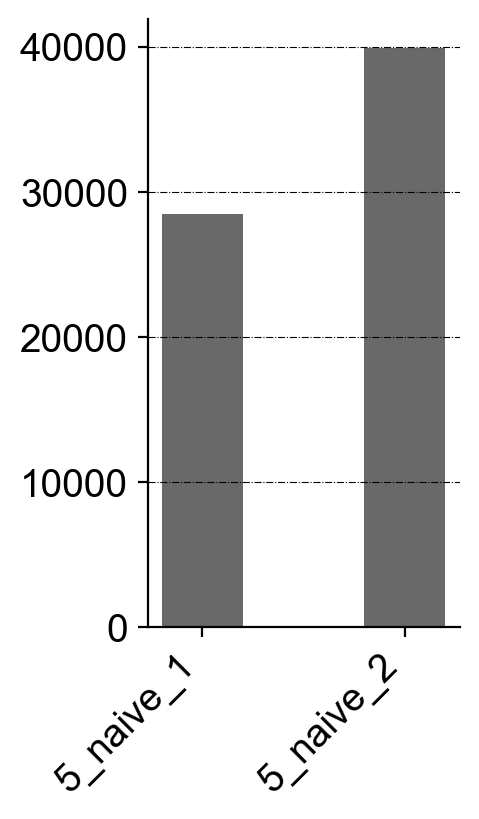

In [8]:
exp_list = []
counts_list = []
for adata in adatas:
    exp = adata.obs.experiment[0]
    counts = adata.n_obs
    exp_list.append(exp)
    counts_list.append(counts)

fig, ax = plt.subplots(figsize = (2, 4))

ax.bar(exp_list, counts_list, color ='dimgray', width = 0.4)
ax.set_xticklabels(exp_list)

ax.grid(False)
ax.grid(color='black', linestyle='-.', linewidth=0.4, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for tick in ax.get_xticklabels():
    tick.set_ha('right')
    tick.set_rotation(45)

### Concatenate and do TCR QC

In [9]:
import anndata
key_list = ['5_naive_1', '5_naive_2']
adata = anndata.concat(adatas, keys = key_list, index_unique='-')

In [10]:
adata.obs['barcode'] = adata.obs.index.tolist()
adata.obs['barcode'] = adata.obs['barcode'].astype("category")

In [11]:
ir.tl.chain_qc(adata)

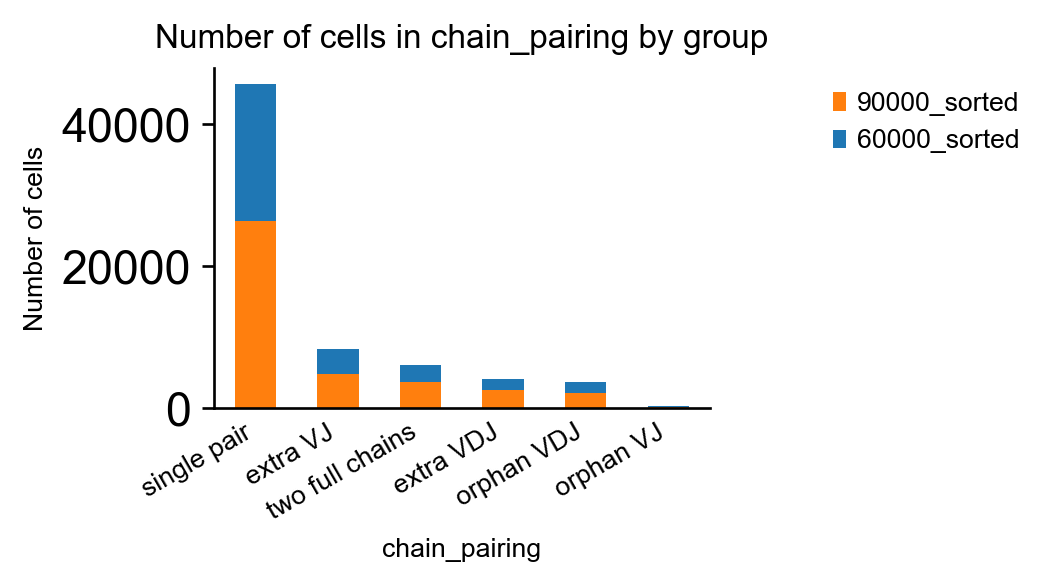

In [12]:
ax=ir.pl.group_abundance(adata, groupby='chain_pairing', target_col='group')
ax.figure.savefig(save_figure_ir + 'chain_pairing_exp.eps')

In [13]:
print('TCR sequencing efficiency: '+str(np.round(adata.obs.has_ir.value_counts(normalize=True)[0]*100,
1))+'%')
print('Unique CDR3 alpha: '+str(adata.obs.IR_VJ_1_junction_aa.append(adata.obs.IR_VJ_2_junction_aa).nunique()))
print('Unique CDR3 beta: '+str(adata.obs.IR_VDJ_1_junction_aa.append(adata.obs.IR_VDJ_2_junction_aa).nunique()))
#print('Multichain counts: '+str(adata.obs.multi_chain.value_counts()['True']))

TCR sequencing efficiency: 100.0%
Unique CDR3 alpha: 41370
Unique CDR3 beta: 61000


In [14]:
print("Fraction of Orphan VJ and VDJ: {:.2f}".format(
        np.sum(
            adata.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]
                                           )
                                )
                                /adata.n_obs * 100
            ) + '%' 
)

Fraction of Orphan VJ and VDJ: 6.06%


Exclude orphan TCRs

In [15]:
adata = adata[adata.obs["has_ir"] != 'None',:]
adata = adata[~adata.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]), :]

### Annotate clonotypes

Nucleotide identification

In [16]:
ir.pp.ir_dist(adata, inplace=True, metric='identity', sequence='nt', key_added='dist_nt_identity', cutoff=0)

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [17]:
ir.tl.define_clonotypes(adata, receptor_arms="all", dual_ir="all", 
                        same_v_gene=True, key_added='clone_id_nt_same_v', n_jobs=32)

ir_dist for sequence='nt' and metric='identity' not found. Computing with default parameters.
Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.
Initializing lookup tables. 
--> Done initializing lookup tables. (0:00:07)
Computing clonotype x clonotype distances.
NB: Computation happens in chunks. The progressbar only advances when a chunk has finished. 


  0%|          | 0/63573 [00:00<?, ?it/s]

--> Done computing clonotype x clonotype distances.  (0:03:44)
Stored clonal assignments in `adata.obs["clone_id_nt_same_v"]`.


<AxesSubplot: >

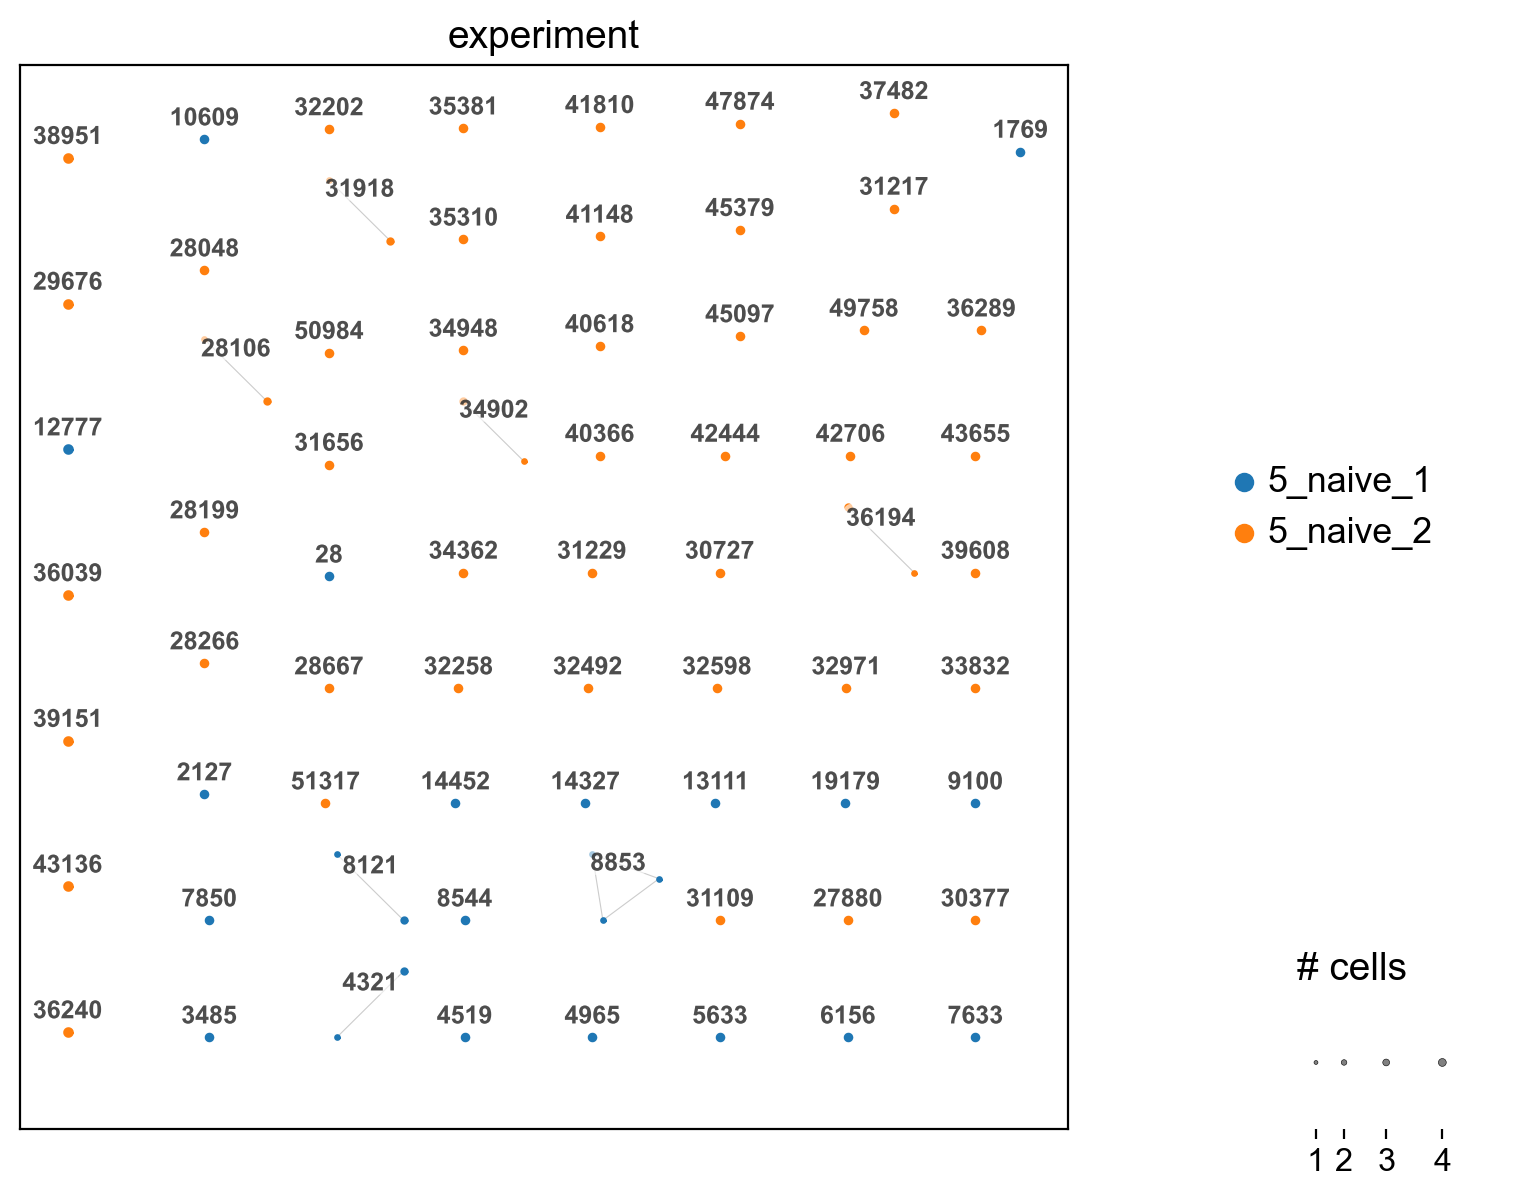

In [18]:
ir.tl.clonotype_network(adata, min_cells=3, clonotype_key='clone_id_nt_same_v')
ir.pl.clonotype_network(
    adata, color="experiment", label_fontsize=9, panel_size=(7, 7), base_size=2
)

#### Amino acid identification

Scirpy states in documentation standard values for metric:identity (cutoff=0) and receptor_arms:all, but somehow didn't work properly - explicitly give these arguments, then same V and cdr3alpha_beta pair identity also works for amino acids


In [19]:
ir.pp.ir_dist(adata, inplace=True, metric='identity', sequence='aa', key_added='dist_aa_identity', cutoff=0)

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [20]:
ir.tl.define_clonotype_clusters(adata, metric="identity", receptor_arms = 'all', sequence="aa", dual_ir = 'primary_only',
                                key_added='clone_id_aa_same_v', 
                                distance_key='dist_aa_identity' , same_v_gene=True,n_jobs=32)

Initializing lookup tables. 
--> Done initializing lookup tables. (0:00:04)
Computing clonotype x clonotype distances.
NB: Computation happens in chunks. The progressbar only advances when a chunk has finished. 


  0%|          | 0/63424 [00:00<?, ?it/s]

--> Done computing clonotype x clonotype distances.  (0:02:26)
Stored clonal assignments in `adata.obs["clone_id_aa_same_v"]`.


In [21]:
ir.tl.define_clonotype_clusters(adata, metric="identity", receptor_arms = 'all', sequence="aa", dual_ir = 'all',
                                key_added='clone_id_aa_dual', 
                                distance_key='dist_aa_identity' , same_v_gene=True,n_jobs=32)

Initializing lookup tables. 
--> Done initializing lookup tables. (0:00:06)
Computing clonotype x clonotype distances.
NB: Computation happens in chunks. The progressbar only advances when a chunk has finished. 


  0%|          | 0/63568 [00:00<?, ?it/s]

--> Done computing clonotype x clonotype distances.  (0:02:45)
Stored clonal assignments in `adata.obs["clone_id_aa_dual"]`.


Same V

<AxesSubplot: >

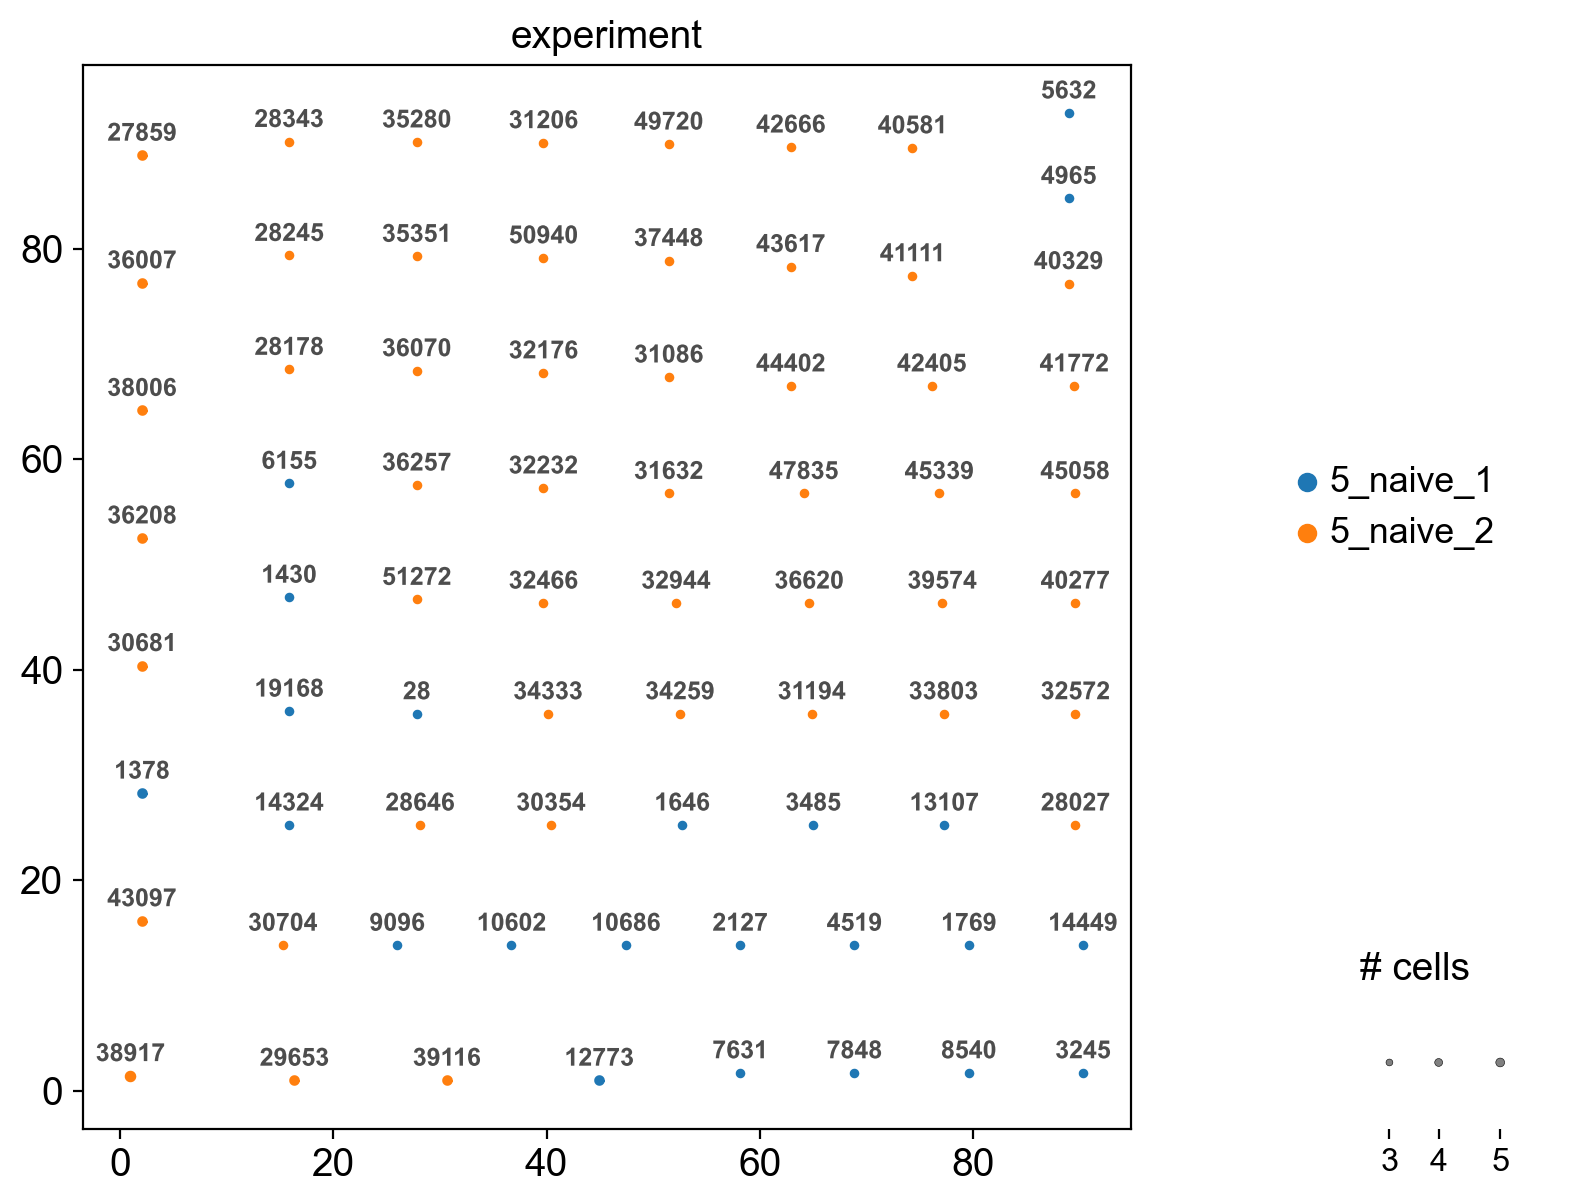

In [22]:
ir.tl.clonotype_network(adata, min_cells=3, clonotype_key='clone_id_aa_same_v')
ir.pl.clonotype_network(
    adata, color="experiment", label_fontsize=9, panel_size=(7, 7), base_size=2
)


Annotate clono type size by donor

In [23]:
adata.obs['mouse'] = 'na'
adata.obs.mouse[adata.obs.experiment == '5_naive_1'] = 'm5_naive_1'
adata.obs.mouse[adata.obs.experiment == '5_naive_2'] = 'm5_naive_2'
adata.obs['mouse'] = adata.obs['mouse'].astype('category')

In [24]:
exp_list = adata.obs.experiment.unique().tolist()
mouse_list = adata.obs.mouse.unique().tolist()

In [25]:
all_clones = adata.obs.clone_id_aa_same_v[adata.obs.clone_id_aa_same_v_size>1].unique().tolist()

In [26]:
adata.obs['clonotype']=adata.obs.clone_id_aa_same_v

In [27]:
adata.obs['clonotype_size']=adata.obs.clone_id_aa_same_v_size

In [28]:
adata.obs['clonotype_size_mouse']=adata.obs.clone_id_aa_same_v_size

In [29]:
for i, mouse in enumerate(mouse_list):
    print(str(i+1), end="\r", flush=True)
    donor_list = adata.obs[adata.obs.mouse==mouse].clone_id_aa_same_v.unique().tolist()
    clone_list = [x for x in donor_list if x in all_clones]
    for clonotype in clone_list:
        adata.obs.clonotype_size_mouse[np.logical_and(adata.obs.mouse==mouse,adata.obs.clonotype==clonotype)] = adata.obs.clonotype[np.logical_and(adata.obs.mouse==mouse,adata.obs.clonotype==clonotype)].value_counts()[0]
        
        

In [30]:
all_clones = adata.obs.clone_id_aa_dual[adata.obs.clone_id_aa_dual_size>1].unique().tolist()

In [31]:
adata.obs['clonotype_dual']=adata.obs.clone_id_aa_dual

In [32]:
adata.obs['clonotype_dual_size']=adata.obs.clone_id_aa_dual_size

In [33]:
adata.obs['clonotype_dual_size_mouse']=adata.obs.clone_id_aa_dual_size

In [34]:
for i, mouse in enumerate(mouse_list):
    print(str(i+1), end="\r", flush=True)
    donor_list = adata.obs[adata.obs.mouse==mouse].clone_id_aa_dual.unique().tolist()
    clone_list = [x for x in donor_list if x in all_clones]
    for clonotype in clone_list:
        adata.obs.clonotype_dual_size_mouse[np.logical_and(adata.obs.mouse==mouse,adata.obs.clonotype_dual==clonotype)] = adata.obs.clonotype_dual[np.logical_and(adata.obs.mouse==mouse,adata.obs.clonotype_dual==clonotype)].value_counts()[0] 
        

In [35]:
adata_file = '01_adata_after_QC_HVG_clonotypes.h5ad'
adata.write(adata_directory+adata_file)

### Check for doublet rate based on multi chain and TCR count identification

Size distribution

In [36]:
adata.obs.clone_id_aa_dual_size.value_counts()

1    62836
2     1192
3      183
4       24
5        5
Name: clone_id_aa_dual_size, dtype: int64

In [37]:
adata.obs.clone_id_nt_same_v_size.value_counts()

1    62845
2     1184
3      183
4       28
Name: clone_id_nt_same_v_size, dtype: int64

Some expanded clones are in the data

In [38]:
df = adata.obs.groupby("clone_id_aa_dual").agg(
        clone_id_aa_dual = ("clone_id_aa_dual", "first"),
        chain_pairing = ("chain_pairing", "first"),
        n_clones_nt = ("clone_id_nt_same_v", "nunique"),
        cdr3a_aa_1 = ("IR_VJ_1_junction_aa", "first"),
        cdr3b_aa_1 = ("IR_VDJ_1_junction_aa", "first"),
        cdr3a_aa_2 = ("IR_VJ_2_junction_aa", "first"),
        cdr3b_aa_2 = ("IR_VDJ_2_junction_aa", "first"),
        mouse = ("mouse",'first'),
    )

In [39]:
df.n_clones_nt.value_counts()

1    63495
2        5
Name: n_clones_nt, dtype: int64

### Check in other naive data set

In [40]:
adata_ref = sc.read('E:\Adrian\SINGLE CELL DATA\Annotation_naive_mice\Annotated_files/03_adata_after_tcr_annotation.h5ad')

In [41]:
df_ref = adata_ref.obs.groupby("clone_id_aa_dual").agg(
    clone_id_aa_dual = ("clone_id_aa_dual", "first"),
    chain_pairing = ("chain_pairing", "first"),
    n_clones_nt = ("clone_id_nt_same_v", "nunique"),
    cdr3a_aa_1 = ("IR_VJ_1_junction_aa", "first"),
    cdr3b_aa_1 = ("IR_VDJ_1_junction_aa", "first"),
    cdr3a_aa_2 = ("IR_VJ_2_junction_aa", "first"),
    cdr3b_aa_2 = ("IR_VDJ_2_junction_aa", "first"),
    mouse = ("mouse",'first'),
)
df_ref["clone_id_aa_dual"] = df_ref["clone_id_aa_dual"].astype(str) + "_exp_1"
df_ref["clone_id_aa_dual"] = df_ref["clone_id_aa_dual"].astype("category")

In [42]:
df = df.reset_index(drop=True)
df_ref = df_ref.reset_index(drop=True)

In [43]:
df = df.append(df_ref)
df = df.reset_index(drop=True)

In [44]:
df.mouse.unique()

array(['m5_naive_1', 'm5_naive_2', 'm1', 'm2', 'm3', 'm4'], dtype=object)

In [45]:
df_plot = pd.DataFrame()
for mouse in df.mouse.unique():
    df_temp = pd.DataFrame(df[df.mouse==mouse].chain_pairing.value_counts())
    sum_repertoire = df[df.mouse==mouse].chain_pairing.value_counts().sum()
    df_temp['mouse'] = mouse
    df_temp['freq'] = (df_temp.chain_pairing/sum_repertoire)*100
    df_plot = df_plot.append(df_temp)
df_plot['chain_label'] = df_plot.index
df_plot = df_plot.reset_index(drop=True)

In [46]:
df_plot

,chain_pairing,mouse,freq,chain_label
0,19073,m5_naive_1,71.829925,single pair
1,3527,m5_naive_1,13.282868,extra VJ
2,2390,m5_naive_1,9.000866,two full chains
3,1563,m5_naive_1,5.886341,extra VDJ
4,25978,m5_naive_2,70.311527,single pair
5,4757,m5_naive_2,12.875200,extra VJ
6,3699,m5_naive_2,10.011638,two full chains
7,2513,m5_naive_2,6.801635,extra VDJ
8,8968,m1,69.611115,single pair
9,1713,m1,13.296592,extra VDJ


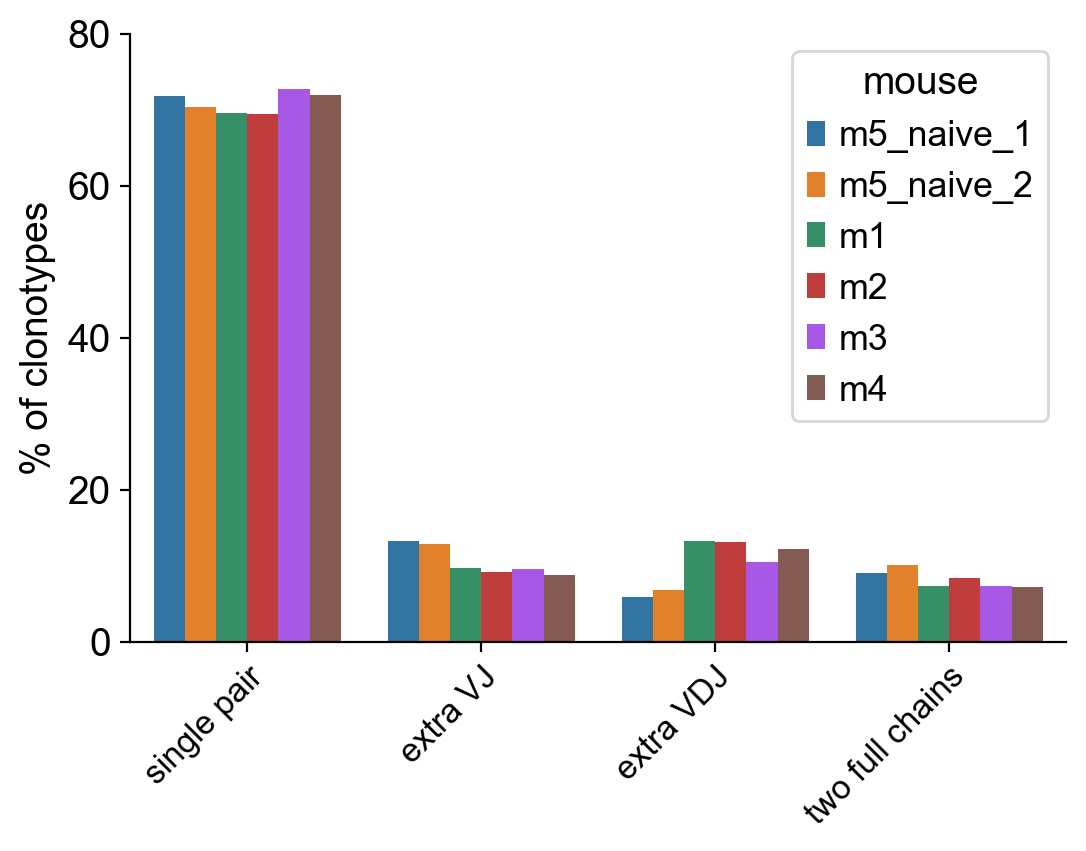

In [47]:
fig, ax = plt.subplots(figsize = (6,4))

labels = ['single pair','extra VJ','extra VDJ','two full chains']
sns.barplot(data = df_plot, x = 'chain_label', y = "freq", order = labels, ax=ax, hue = 'mouse')

ax.set_xticklabels(labels, fontsize=12, rotation=45, ha='right', rotation_mode="anchor")

ax.set_ylabel("% of clonotypes")
ax.set_xlabel("")
ax.set_ylim(0,80)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



Multi chain detection fits with prior sequencing data - no indication that new Kit or larger numbers introduced cell doublets

In [48]:
adata.obs['specificity'] = 'not_identified'
adata.obs['specificity'] = adata.obs['specificity'].astype('category')

In [49]:
tcr_list = adata.obs.clone_id_aa_dual.unique().tolist()

In [50]:
%%time

from tqdm import tqdm

#input clone ids
clone_list = tcr_list
#input barcodes from clonotypes to extract TCR sequences
barcode_list = []
alpha_1_list = []
alpha_2_list = []
beta_1_list = []
beta_2_list = []

# sort relevant obs columns by TCR identification to pick most reliable single cell barcode
filtered_df = adata[adata.obs.clone_id_aa_dual.isin(clone_list)].obs[[
    'clone_id_aa_dual', 'IR_VJ_1_consensus_count', 'IR_VDJ_1_consensus_count', 'clonotype_dual_size_mouse', 
    'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa']].sort_values(
            by=['clone_id_aa_dual', 'clonotype_dual_size_mouse', 'IR_VJ_1_consensus_count', 
            'IR_VDJ_1_consensus_count'], ascending=[True, False, False, False])

# Initialize lists
barcode_list = []
alpha_1_list = []
alpha_2_list = []
beta_1_list = []
beta_2_list = []

# Group the pre-filtered DataFrame by 'clone_id_dual'
grouped = filtered_df.groupby('clone_id_aa_dual')

# Iterate over the clone list and collect data
for i, clone in enumerate(tqdm(clone_list, desc="Processing clones")):
    df_temp = grouped.get_group(clone)
    
    barcode_list.append(df_temp.index[0])
    #primary chains are annotated
    alpha_1_list.append(df_temp.IR_VJ_1_junction_aa.iloc[0])
    alpha_2_list.append(df_temp.IR_VJ_2_junction_aa.iloc[0])
    beta_1_list.append(df_temp.IR_VDJ_1_junction_aa.iloc[0])
    beta_2_list.append(df_temp.IR_VDJ_2_junction_aa.iloc[0])
    
    #print(f"processed clones: {i + 1} of {len(tcr_list)}", end="\r", flush=True)

barcode_exp_list = []
mouse_list = []
specificity_list = []
chain_pairing_list = []

# Pre-fetch the necessary data for all barcodes in barcode_list
required_columns = ['experiment', 'mouse', 'specificity', 'chain_pairing']
filtered_df = adata.obs.loc[barcode_list, required_columns]

# Iterate over the barcode list and collect data
for barcode in tqdm(barcode_list, desc="Processing barcodes"):
    exp = filtered_df.at[barcode, 'experiment']
    mouse = filtered_df.at[barcode, 'mouse']
    spec = filtered_df.at[barcode, 'specificity']
    chain = filtered_df.at[barcode, 'chain_pairing']
    
    barcode_exp_list.append(exp)
    mouse_list.append(mouse)
    specificity_list.append(spec)
    chain_pairing_list.append(chain)
    
    #print(f"processed barcodes: {i + 1} of {len(barcode_list)}", end="\r", flush=True)

    
print("loading VDJ files...")

naive_1 = '.\\gex_vdj\\'
naive_2 = '.\\gex_vdj\\'

#get unique experiments and load VDJ files                 ####### unnecessary copy paste code due to lazyness (other extractions combined multple experiments at the same time)
unique_exp = list(set(barcode_exp_list))

csv_path =  []
json_path = []
    
for i, exp in enumerate(unique_exp):
    if '5_naive_1' in exp:
        filename_csv = glob.glob(f'{naive_1}/VDJ_1/outs/filtered_contig_annotations.csv')
        filename_json = glob.glob(f'{naive_1}/VDJ_1/outs/all_contig_annotations.json')
    elif '5_naive_2' in exp:
        filename_csv = glob.glob(f'{naive_2}/VDJ_2/outs/filtered_contig_annotations.csv')
        filename_json = glob.glob(f'{naive_2}/VDJ_2/outs/all_contig_annotations.json')
    else:
        break
    csv_path.append(filename_csv)
    json_path.append(filename_json)
    

filename_json_list = []
filename_csv_list = []

#load contigs
for csv, vdj in tqdm(zip(csv_path, json_path), desc="Loading contigs", total=len(csv_path)):
    filename_csv_list.append(pd.read_csv(csv[0]))
    filename_json_list.append(pd.read_json(vdj[0]))
      

print("VDJ files loaded...")


#This generates a dataframe that compares the isolated barcode (see above) to the
#filtered_contig_annotation file from the vdj data to extract the complete TCR sequence
df_template = pd.DataFrame()
df_template2 = pd.DataFrame()

#global df_temp
contig_list = ['_contig_1','_contig_2','_contig_3','_contig_4']
contig_anot_alpha = ['1','1','2','2']
contig_anot_beta = ['1','1','1','2']

print("Starting sequence extraction and writing to file...")

for i, barcode in enumerate(tqdm(barcode_list, desc="Processing sequence extraction")):
    exp = barcode_exp_list[i]
    position = unique_exp.index(exp)
    sequences = filename_json_list[position]
    df = filename_csv_list[position]
    
    # Prepare the initial DataFrame from json and csv files
    df_temp = pd.DataFrame({
        'barcode': [barcode],
        'chain_pairing': [chain_pairing_list[i]],
        'exp': [exp],
        'mouse': [mouse_list[i]],
        'clonotype': [clone_list[i]],
        'specificity': [specificity_list[i]],
        'first_alpha': [alpha_1_list[i]],
        'second_alpha': [alpha_2_list[i]],
        'first_beta': [beta_1_list[i]],
        'second_beta': [beta_2_list[i]]
    })
    
    
    tra_count = 0
    trb_count = 0

    barcode_prefix = barcode[:18]
    
    df_temp2 = df[df.barcode == barcode_prefix].copy()
    df_temp2['clonotype'] = clone_list[i]
    df_temp2['chain_pairing'] = chain_pairing_list[i]
    df_temp2['exp'] =  barcode_exp_list[i]
    df_temp2['specificity'] = specificity_list[i]
    df_temp2['first_alpha'] = alpha_1_list[i]
    df_temp2['second_alpha'] = alpha_2_list[i]
    df_temp2['first_beta'] = beta_1_list[i]
    df_temp2['second_beta'] = beta_2_list[i]
    
    for contig in contig_list:
        df_ref = df[df.contig_id == barcode_prefix + contig]

        if not df_ref.empty:
            try:
                if df_ref.chain.values[0] == 'TRA':
                    tra_count += 1
                    df_temp[f'trav_{tra_count}'] = df_ref.v_gene.values[0]
                    df_temp[f'traj_{tra_count}'] = df_ref.j_gene.values[0]
                    df_temp[f'trac_{tra_count}'] = df_ref.c_gene.values[0]
                    df_temp[f'alpha_umi_{tra_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'read_count'].values[0]
                    df_temp[f'cdr3_alpha_nt_{tra_count}'] = df_ref.cdr3_nt.values[0]
                    df_temp[f'cdr3_alpha_aa_{tra_count}'] = df_ref.cdr3.values[0]
                    df_temp[f'full_alpha_nt_{tra_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'sequence'].values[0]
                    df_temp[f'full_alpha_aa_{tra_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'aa_sequence'].values[0]
                else:
                    trb_count += 1
                    df_temp[f'trbv_{trb_count}'] = df_ref.v_gene.values[0]
                    df_temp[f'trbj_{trb_count}'] = df_ref.j_gene.values[0]
                    df_temp[f'trbd_{trb_count}'] = df_ref.d_gene.values[0]
                    df_temp[f'trbc_{trb_count}'] = df_ref.c_gene.values[0]
                    df_temp[f'beta_umi_{trb_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'read_count'].values[0]
                    df_temp[f'cdr3_beta_nt_{trb_count}'] = df_ref.cdr3_nt.values[0]
                    df_temp[f'cdr3_beta_aa_{trb_count}'] = df_ref.cdr3.values[0]
                    df_temp[f'full_beta_nt_{trb_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'sequence'].values[0]
                    df_temp[f'full_beta_aa_{trb_count}'] = sequences.loc[sequences.contig_name == barcode_prefix + contig, 'aa_sequence'].values[0]
            except KeyError:
                pass
    
    df_template = pd.concat([df_template, df_temp], ignore_index=True)
    df_template2 = pd.concat([df_template2, df_temp2], ignore_index=True)

df_template.to_excel('./tcr_seq_output/all_tcr_seqs_tcrs_json.xlsx')
df_template.to_csv('./tcr_seq_output/all_tcr_seqs_tcrs_json.csv', index=False)

df_template2.to_excel('./tcr_seq_output/all_tcr_seqs_tcrs_csv_cell_ranger_format.xlsx')
df_template2.to_csv('./tcr_seq_output/all_tcr_seqs_tcrs_csv_cell_ranger_format.csv', index=False)

Processing barcodes: 100%|████████████████████████████████████████████████████| 63500/63500 [00:02<00:00, 27126.33it/s]


loading VDJ files...


Loading contigs: 100%|███████████████████████████████████████████████████████████████████| 2/2 [00:27<00:00, 13.60s/it]


VDJ files loaded...
Starting sequence extraction and writing to file...


Processing sequence extraction: 100%|██████████████████████████████████████████| 63500/63500 [5:18:58<00:00,  3.32it/s]


CPU times: total: 4h 42min 47s
Wall time: 5h 23min 54s
